# Heart Prediction


|                |   |
:----------------|---|
| **Nombre**     |  Jorge Oviedo Magaña |
| **Fecha**      | 06/04/2026 |
| **Expediente** |  757048 | 

In [31]:
import pandas as pd

df = pd.read_csv("Heart Prediction Quantum Dataset.csv")

df.info()

# genero a categorico
# enfermedad cardiaca a bool 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    500 non-null    int64  
 1   Gender                 500 non-null    int64  
 2   BloodPressure          500 non-null    int64  
 3   Cholesterol            500 non-null    int64  
 4   HeartRate              500 non-null    int64  
 5   QuantumPatternFeature  500 non-null    float64
 6   HeartDisease           500 non-null    int64  
dtypes: float64(1), int64(6)
memory usage: 27.5 KB


In [32]:
df.describe()

# edad = años
# presion = mmHg
# ritmo = bpm
# colesterol = mg/dl

,Age,Gender,BloodPressure,Cholesterol,HeartRate,QuantumPatternFeature,HeartDisease
count,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.000000
mean,54.864000,0.468000,132.874000,221.50000,88.766000,8.317407,0.600000
std,14.315004,0.499475,26.418516,43.86363,17.417289,0.919629,0.490389
min,30.000000,0.000000,90.000000,150.00000,60.000000,6.164692,0.000000
25%,43.000000,0.000000,111.000000,183.75000,73.000000,7.675779,0.000000
50%,55.000000,0.000000,132.000000,221.00000,89.000000,8.323064,1.000000
75%,66.250000,1.000000,155.000000,258.00000,104.000000,8.935999,1.000000
max,79.000000,1.000000,179.000000,299.00000,119.000000,10.784886,1.000000


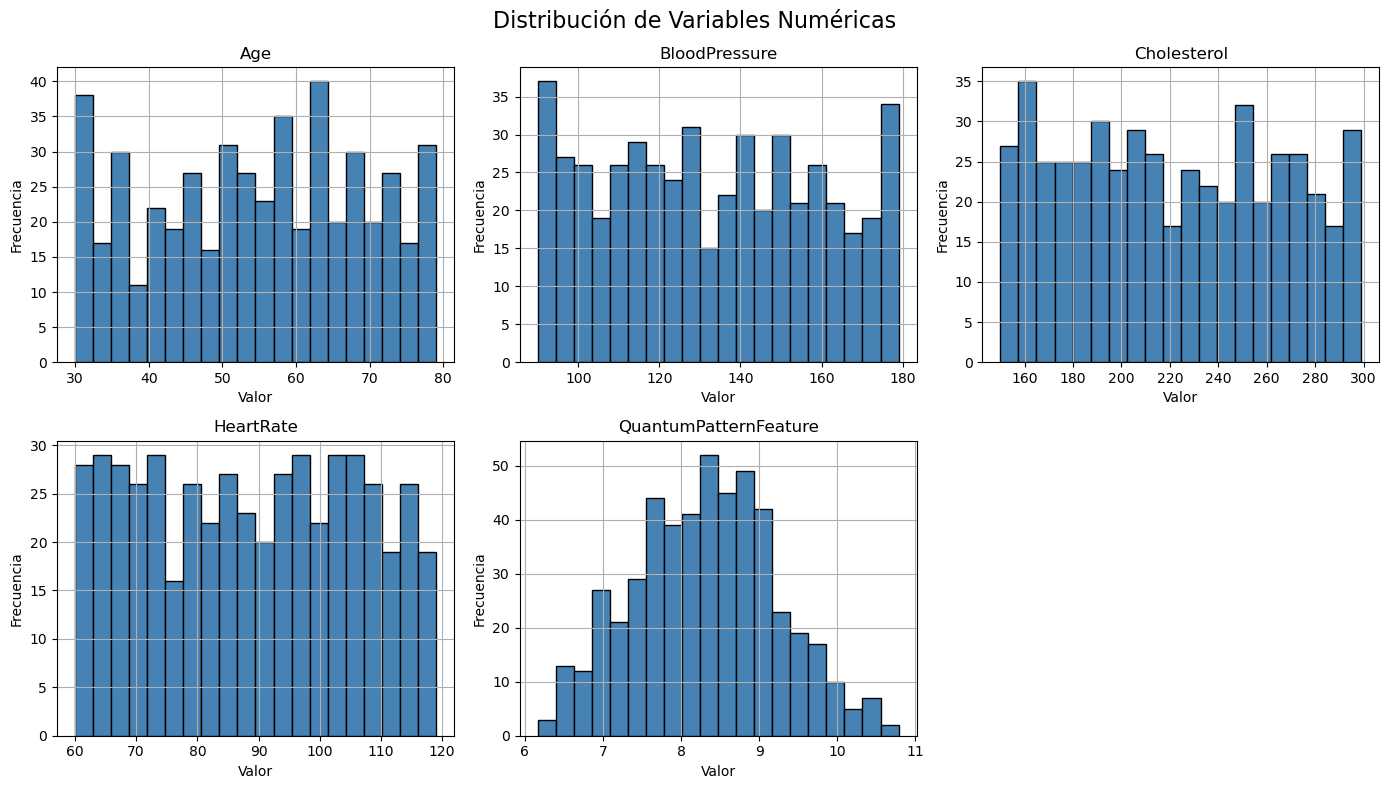

In [33]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Distribución de Variables Numéricas', fontsize=16)

cols = ['Age', 'BloodPressure', 'Cholesterol', 'HeartRate', 'QuantumPatternFeature']

for i, col in enumerate(cols):
    ax = axes[i // 3][i % 3]
    df[col].hist(ax=ax, bins=20, edgecolor='black', color='steelblue')
    ax.set_title(col)
    ax.set_xlabel('Valor')
    ax.set_ylabel('Frecuencia')

axes[1][2].set_visible(False)  # ocultar subplot vacío

plt.tight_layout()
plt.show()

In [34]:
#Aqui haces el EDA (buscas el promedio para ver como estan los de esta muestra)

# edad = int = años [30,79] rango max,mins
# genero = cat = [0,1]
# presión sanguínea (sistólica) = int = mmHg [90,179]
# Ritmo Cardiaco (reposo) = int = bpm [60, 119] -> es bajo tiene que ser en reposo
# Colesterol (total) = int = mg/dl [150, 299] -> es muy alto tiene que ser total

In [35]:
print("=== PROMEDIOS DE LA MUESTRA ===")
print(df[['Age', 'BloodPressure', 'Cholesterol', 'HeartRate', 'QuantumPatternFeature']].mean().round(2))

print("\n=== DISTRIBUCIÓN DE GÉNERO ===")
print(df['Gender'].value_counts())

print("\n=== DISTRIBUCIÓN DE ENFERMEDAD CARDÍACA ===")
print(df['HeartDisease'].value_counts())

=== PROMEDIOS DE LA MUESTRA ===
Age                       54.86
BloodPressure            132.87
Cholesterol              221.50
HeartRate                 88.77
QuantumPatternFeature      8.32
dtype: float64

=== DISTRIBUCIÓN DE GÉNERO ===
Gender
0    266
1    234
Name: count, dtype: int64

=== DISTRIBUCIÓN DE ENFERMEDAD CARDÍACA ===
HeartDisease
1    300
0    200
Name: count, dtype: int64


-------------------------------------------------------------------------------------------------------------------------------------

In [42]:
# Variables
X = df.drop(columns=['HeartDisease', 'QuantumPatternFeature'])
y = df['HeartDisease']

#-------ingenieria de caracteristicas------------

Xnum = ['Age', 'BloodPressure', 'Cholesterol', 'HeartRate']
Xcat = ['Gender']

In [43]:
#pipeline

from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler


model = MLPClassifier(hidden_layer_sizes=(5, 10), random_state=42)
num_cols = ('num', StandardScaler(), Xnum)
cat_cols = ('cat', 'passthrough', Xcat)

# Preprocesamiento
preprocessor = ColumnTransformer(transformers=[num_cols, cat_cols])

# Pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', model)
])

pipeline.fit(X,y)

print(pipeline.score(X, y))

0.804


c:\Users\jorgo\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [44]:
from sklearn.model_selection import cross_val_score, KFold

cv = KFold(n_splits=10, shuffle=True, random_state=42)
cv_scores = cross_val_score(pipeline, X, y, cv=cv,scoring="roc_auc")


c:\Users\jorgo\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\jorgo\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\jorgo\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\jorgo\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\jorgo\anaconda3\Lib\site-packages\sklearn\neural_network\_multi